In [1]:
import json
import re
import numpy as np
import pandas as pd
import re
from scipy.stats import pointbiserialr, spearmanr, ttest_ind, mannwhitneyu
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import pingouin as pg
from tqdm import tqdm
from transformers import AutoTokenizer
import rich

In [2]:
with open('/data/user_data/wenkail/sotopia_diplomacy/processed_data_analysis/500_sample_with_taskeval_supply_center_qwen_judge.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]

In [13]:
games_with_winner = []
for game in tqdm(data):
    last_phase = game['phases'][-1]
    centers = last_phase['state']['centers']
    game_with_winner = json.loads(json.dumps(game))
    game_with_winner['winner'] = []
    game_with_winner['losers'] = []
    for country, centers_list in centers.items():
        if len(centers_list) >= 18:
            game_with_winner['winner'] = country
        if len(centers_list) == 0:
            game_with_winner['losers'].append(country)
    if game_with_winner['winner'] != [] and game_with_winner['losers'] != []:
        games_with_winner.append(game_with_winner)

100%|██████████| 471/471 [00:14<00:00, 33.17it/s]


In [14]:
len(games_with_winner)

213

In [17]:
games_with_winner[0]

{'id': '1727',
 'map': 'standard',
 'rules': ['NO_PRESS', 'POWER_CHOICE'],
 'phases': [{'name': 'S1901M',
   'state': {'timestamp': 1711385725218381,
    'zobrist_hash': '1919110489198082658',
    'note': '',
    'name': 'S1901M',
    'units': {'AUSTRIA': ['A BUD', 'A VIE', 'F TRI'],
     'ENGLAND': ['F EDI', 'F LON', 'A LVP'],
     'FRANCE': ['F BRE', 'A MAR', 'A PAR'],
     'GERMANY': ['F KIE', 'A BER', 'A MUN'],
     'ITALY': ['F NAP', 'A ROM', 'A VEN'],
     'RUSSIA': ['A WAR', 'A MOS', 'F SEV', 'F STP/SC'],
     'TURKEY': ['F ANK', 'A CON', 'A SMY']},
    'retreats': {'AUSTRIA': {},
     'ENGLAND': {},
     'FRANCE': {},
     'GERMANY': {},
     'ITALY': {},
     'RUSSIA': {},
     'TURKEY': {}},
    'centers': {'AUSTRIA': ['BUD', 'TRI', 'VIE'],
     'ENGLAND': ['EDI', 'LON', 'LVP'],
     'FRANCE': ['BRE', 'MAR', 'PAR'],
     'GERMANY': ['BER', 'KIE', 'MUN'],
     'ITALY': ['NAP', 'ROM', 'VEN'],
     'RUSSIA': ['MOS', 'SEV', 'STP', 'WAR'],
     'TURKEY': ['ANK', 'CON', 'SMY']},
  

In [ ]:
# 只统计winner，并且只考虑winner作为sender的message
# 参考 @file_context_0 的写法，按year聚合，并统计8个feature的出现次数

# 需要用到的feature_name_map和extract_answers_after_think
feature_name_map = {
    'feature_0_yes_binary': "1. Game-Move",
    'feature_1_yes_binary': "2. Reasoning",
    'feature_2_yes_binary': "3. Rapport",
    'feature_3_yes_binary': "4. Apologies",
    'feature_4_yes_binary': "5. Compliment",
    'feature_5_yes_binary': "6. Personal-Thoughts",
    'feature_6_yes_binary': "7. Reassurance",
    'feature_7_yes_binary': "8. Share-Information"
}

def extract_answers_after_think(s):
    # 假设llm_judgement是8行，每行以"yes"或"no"结尾
    # 例如: "1. Game-Move: yes"
    if not s or not isinstance(s, str):
        return []
    lines = s.strip().split('\n')
    results = []
    for line in lines:
        m = re.search(r'(yes|no)\s*$', line.strip().lower())
        if m:
            results.append(m.group(1))
    return results

def extract_year(phase_name):
    # phase_name like 'S1901M', 'F1902A', etc.
    m = re.match(r'[SWF](\d{4})', phase_name)
    if m:
        return int(m.group(1))
    return None

winner_yearly_stats = []

for game in games_with_winner:
    winner = game['winner']
    game_id = game.get('id')
    phases = game.get('phases', [])
    # 按year聚合phase
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        year = extract_year(phase_name)
        if year is None:
            continue
        year_to_phases.setdefault(year, []).append(phase)
    for year, year_phases in year_to_phases.items():
        # winner每年所有phase的center_count, center_increase, taskeval
        center_counts = []
        center_increases = []
        taskevals = []
        winner_messages = []
        feature_counts = np.zeros(8, dtype=int)
        for phase in year_phases:
            center_info = phase.get('center_info', {})
            taskeval_info = phase.get('taskeval', {})
            if winner in center_info:
                center_counts.append(center_info[winner].get('center_count', np.nan))
                center_increases.append(center_info[winner].get('center_increase', np.nan))
            if winner in taskeval_info:
                taskevals.append(taskeval_info[winner])
            # 只统计winner作为sender的message
            for msg in phase.get('messages', []):
                if msg is not None and msg.get('sender') == winner:
                    winner_messages.append(msg.get('message', ''))
                    s = msg.get('llm_judgement')
                    if not s:
                        continue
                    matches = extract_answers_after_think(s)
                    if len(matches) != 8:
                        continue
                    for i, val in enumerate(matches):
                        if val == 'yes':
                            feature_counts[i] += 1
        # 聚合
        stat = {
            'game_id': game_id,
            'winner': winner,
            'year': year,
            'center_count_mean': center_counts[-1] if center_counts else np.nan,
            'center_increase_sum': np.nansum(center_increases) if center_increases else np.nan,
            'taskeval_mean': np.nanmean(taskevals) if taskevals else np.nan,
            'message_count': len(winner_messages),
            'all_messages': "\n".join(winner_messages)
        }
        # 加入8个feature的出现次数
        for i in range(8):
            stat[f'feature_{i}_yes_count'] = feature_counts[i]
        winner_yearly_stats.append(stat)

# 应用特征名映射
df_winner_yearly = pd.DataFrame(winner_yearly_stats)
# 只对feature count列做rename
feature_count_rename = {f'feature_{i}_yes_count': feature_name_map[f'feature_{i}_yes_binary'] + "_count" for i in range(8)}
df_winner_yearly = df_winner_yearly.rename(columns=feature_count_rename)


,game_id,winner,year,center_count_mean,center_increase_sum,taskeval_mean,message_count,all_messages,1. Game-Move_count,2. Reasoning_count,3. Rapport_count,4. Apologies_count,5. Compliment_count,6. Personal-Thoughts_count,7. Reassurance_count,8. Share-Information_count
0,1727,FRANCE,1901,6,3,-0.036895,6,"Short and direct. I'm gonna like you, England....",0,1,1,1,0,0,1,0
1,1727,FRANCE,1902,6,0,0.083117,1,I was thinking I would take Holland and Munich...,1,0,0,0,0,0,0,0
2,1727,FRANCE,1903,8,2,-0.004024,11,Convoy to where? Kiel? I'll try for Munich thi...,3,0,0,0,0,0,0,1
3,1727,FRANCE,1904,9,1,-0.017345,5,Personally... I think we should at least kill ...,3,0,0,0,0,0,0,1
4,1727,FRANCE,1905,10,1,0.042752,4,I'd like to take Vienna. Wanna split the rest ...,2,0,0,0,0,0,0,0


In [33]:
df_winner_yearly.year.value_counts()

year
1901    213
1902    213
1903    213
1904    213
1905    213
1906    213
1907    213
1908    213
1909    213
1910    192
1911     30
1912     12
1913      3
Name: count, dtype: int64

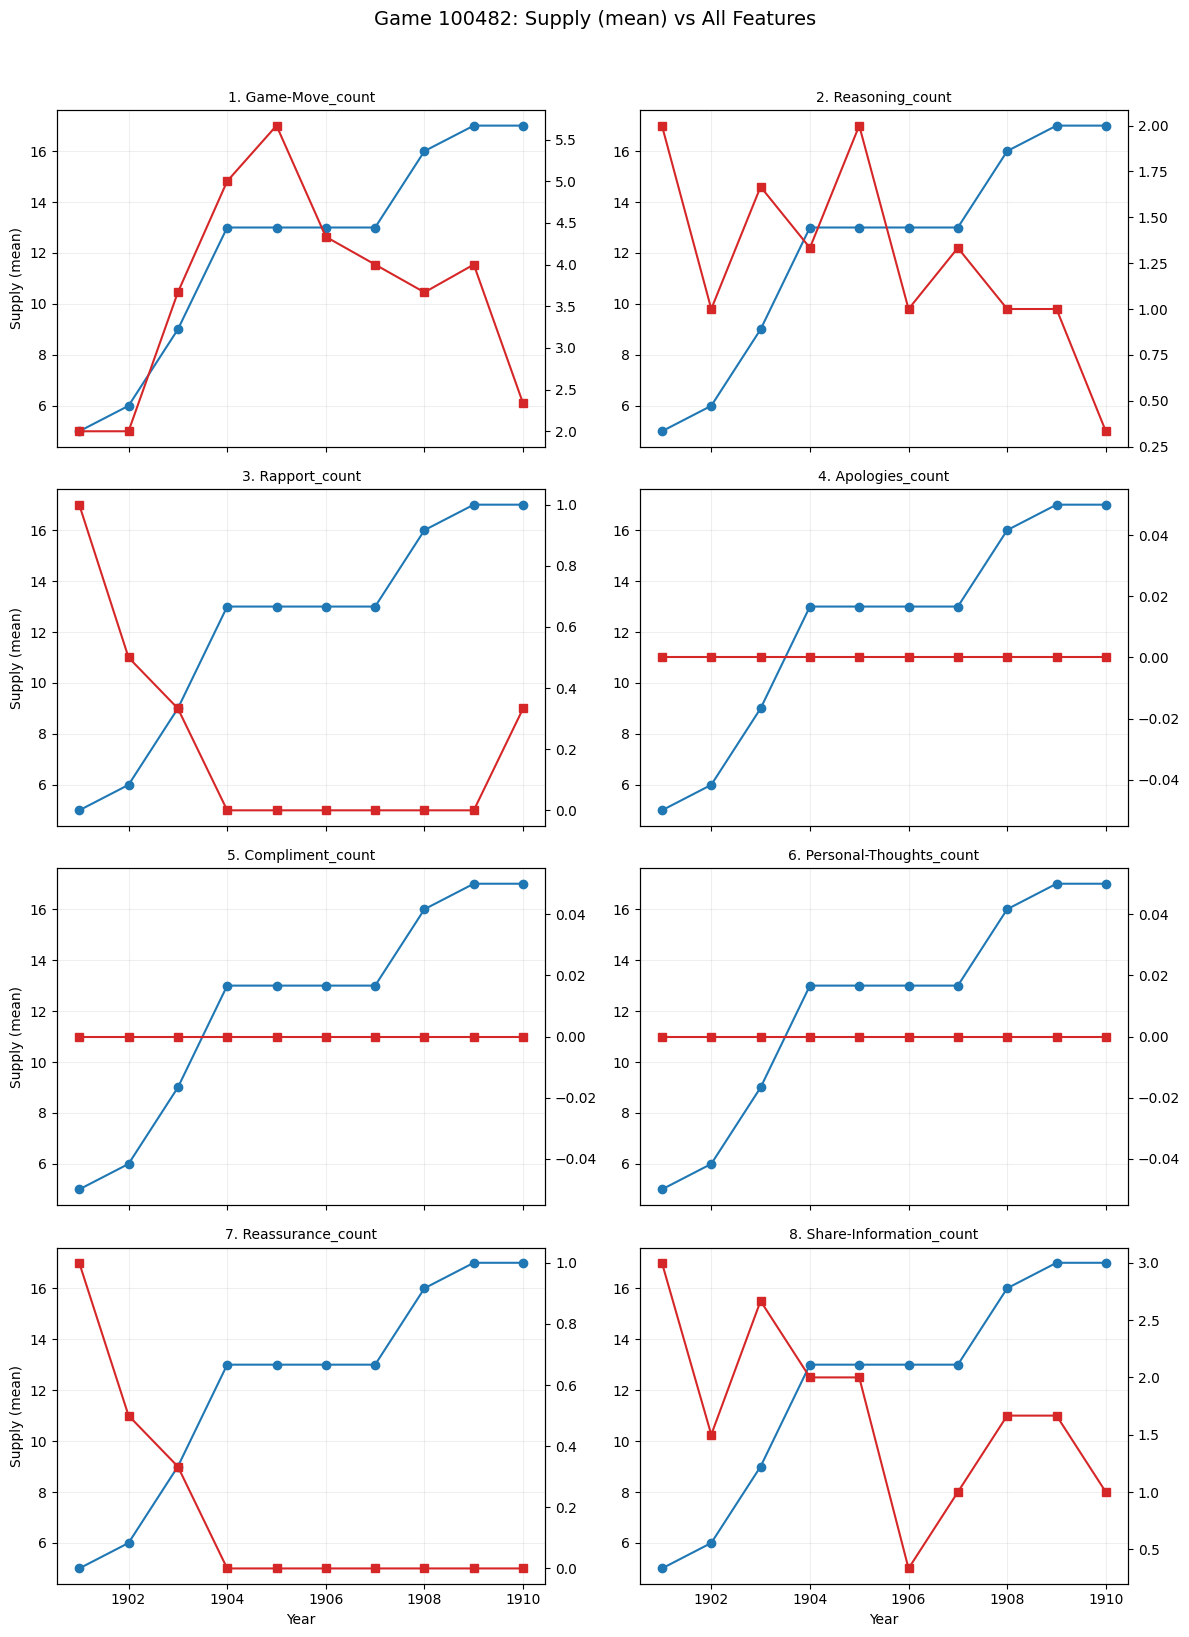

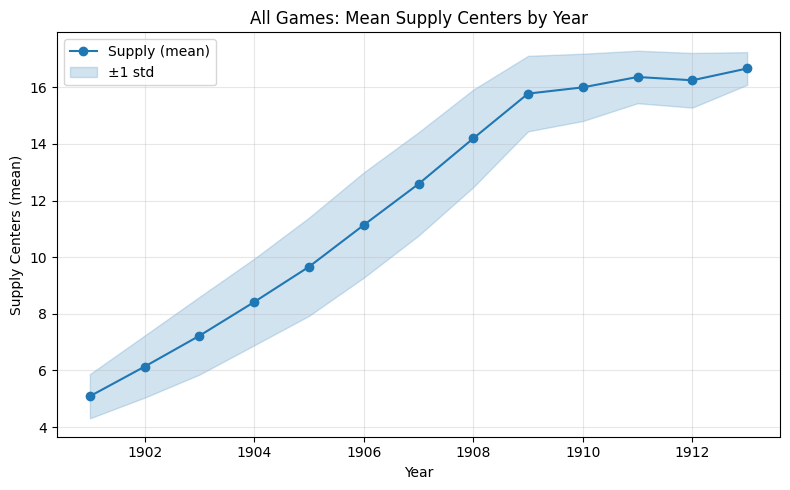

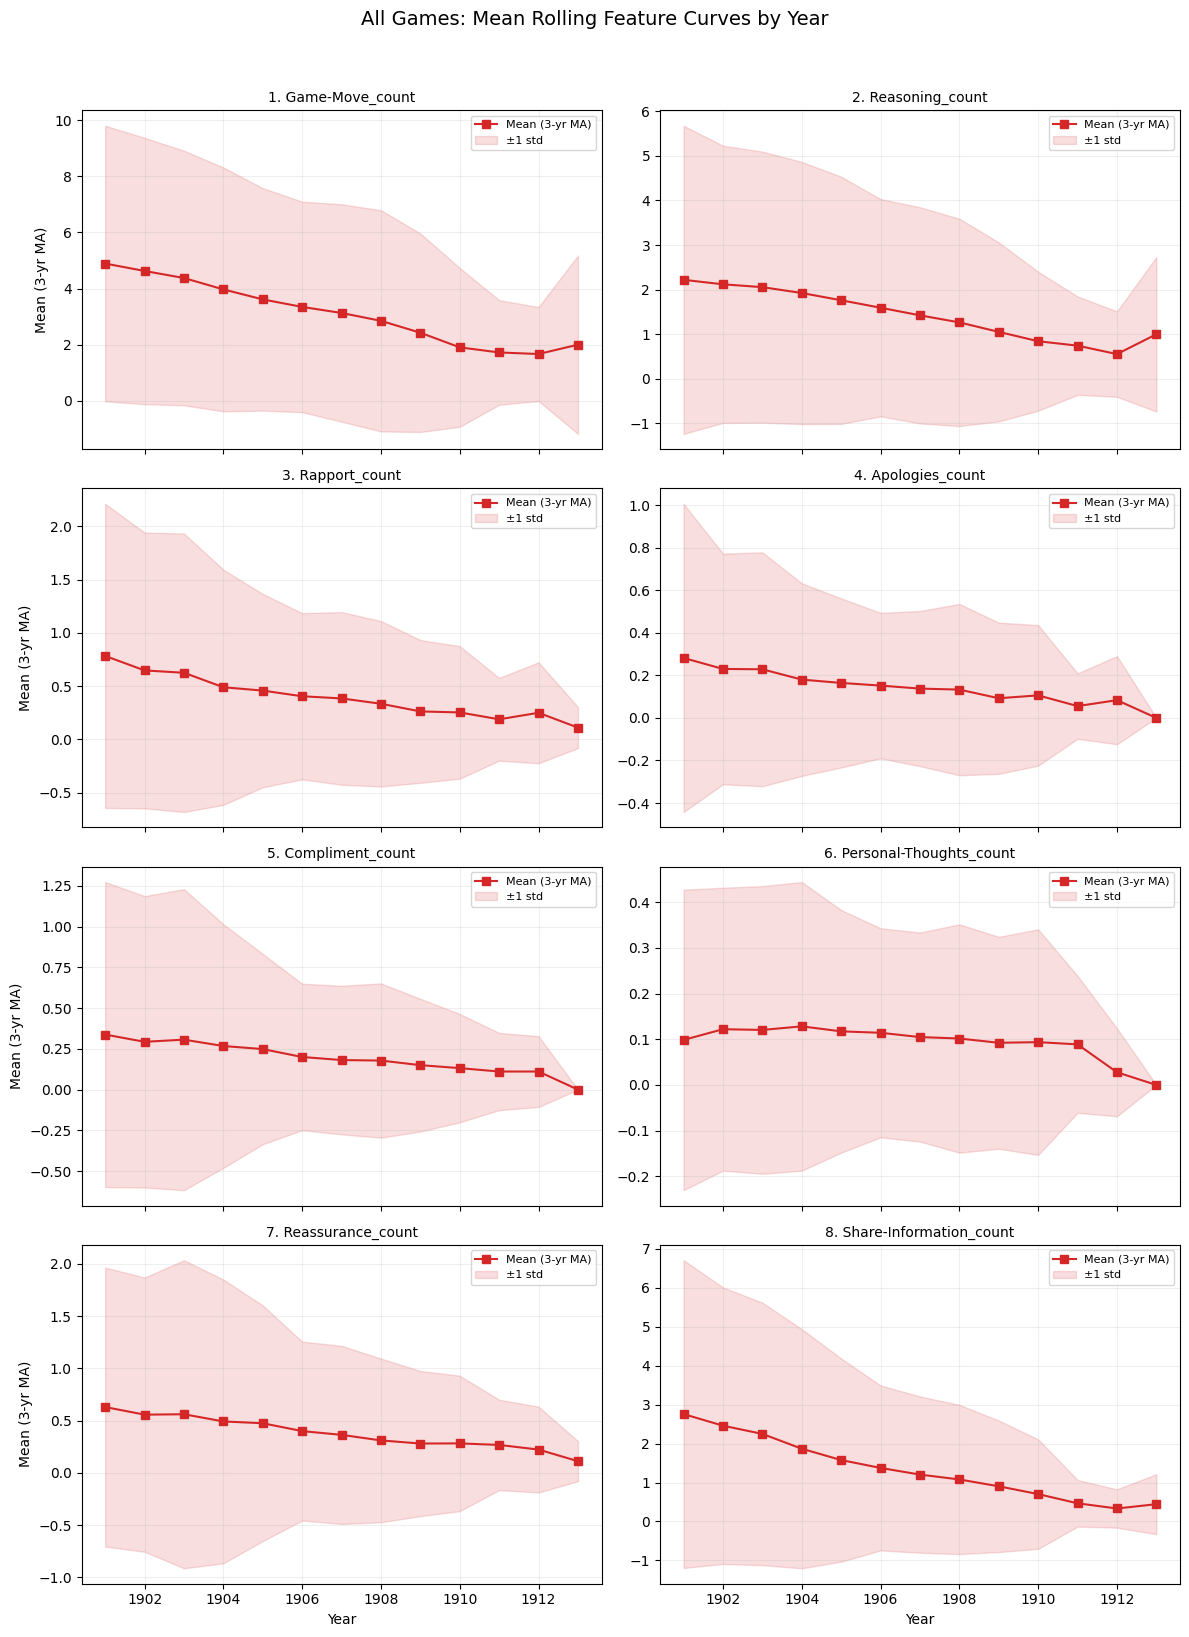


Lag-1 correlation (feature_t  vs  supply_gain_{t+1})
         1. Game-Move_count  2. Reasoning_count  3. Rapport_count  \
game_id                                                             
100482             0.273861            0.458131         -0.079057   
10076             -0.197212           -0.066248         -0.129099   
101587             0.325000            0.319505               NaN   
101966            -0.322581           -0.379797         -0.624958   
101971            -0.131036                 NaN               NaN   

         4. Apologies_count  5. Compliment_count  6. Personal-Thoughts_count  \
game_id                                                                        
100482                  NaN                  NaN                         NaN   
10076             -0.130558            -0.045899                    0.063161   
101587             0.316228                  NaN                    0.671984   
101966            -0.628619            -0.224507              

In [37]:
# ========================================================
# core_analysis.py  –  长期轨迹 + 多特征对照 + 扩展指标
# ========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --------------------------------------------------------
# 0) 参数区
# --------------------------------------------------------
YEAR_COL        = "year"
GAME_ID_COL     = "game_id"
SUPPLY_COL      = "center_count_mean"     # 当前拥有 supply centers
SUPPLY_GAIN_COL = "center_increase_sum"   # 当年净增 supply centers

FEATURE_COLS = [   # 所有计数字段
    "1. Game-Move_count", "2. Reasoning_count", "3. Rapport_count",
    "4. Apologies_count", "5. Compliment_count", "6. Personal-Thoughts_count",
    "7. Reassurance_count", "8. Share-Information_count"
]

SEGMENT_BINS = {"early": (1901, 1903), "mid": (1904, 1906), "late": (1907, 1910)}

# --------------------------------------------------------
# 1) 主函数：预处理 + 派生列
# --------------------------------------------------------
def preprocess(df_raw: pd.DataFrame) -> pd.DataFrame:
    """派生 rolling / slope 列并返回新 DF（不再累计cumsum，直接用mean value）"""
    df = df_raw.copy().sort_values([GAME_ID_COL, YEAR_COL]).reset_index(drop=True)
    g = df.groupby(GAME_ID_COL)

    # Supply/feature rolling mean/slope
    for col in [SUPPLY_COL, SUPPLY_GAIN_COL] + FEATURE_COLS:
        df[f"roll_{col}"]  = g[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
        df[f"slope_{col}"] = g[col].diff().rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    return df

# --------------------------------------------------------
# 2) 可视化工具
# --------------------------------------------------------
def plot_game_pair(df, game_id, feature, save_dir=None):
    """双 Y 轴：Supply mean vs 任意特征滚动平均（均为mean value，不再累计）"""
    gdf = df[df[GAME_ID_COL] == game_id]

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(gdf[YEAR_COL], gdf[SUPPLY_COL], marker="o",
             label="Supply Centers (mean)")
    ax1.set_ylabel("Supply Centers (mean)")
    ax1.set_xlabel("Year")

    ax2 = ax1.twinx()
    ax2.plot(gdf[YEAR_COL], gdf[f"roll_{feature}"], color="tab:red",
             marker="s", label=f"Rolling {feature}")
    ax2.set_ylabel(f"{feature} (3-yr MA)")

    lines, labels = ax1.get_legend_handles_labels()
    l2, lab2      = ax2.get_legend_handles_labels()
    ax1.legend(lines + l2, labels + lab2, loc="upper left")
    ax1.set_title(f"Game {game_id}: Supply (mean) vs {feature}")
    ax1.grid(alpha=.3)
    plt.tight_layout()

    if save_dir:
        Path(save_dir).mkdir(exist_ok=True)
        fname = Path(save_dir) / f"{game_id}_{feature.replace(' ', '_')}.png"
        plt.savefig(fname, dpi=200)
    plt.close()

def plot_all_features_grid(df, game_id, cols=FEATURE_COLS, ncols=2):
    """一次性画完 Supply(mean)-vs-所有特征的网格图（只显示不保存）"""
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows),
                             sharex=True)
    axes = axes.flatten()

    for i, feat in enumerate(cols):
        gdf = df[df[GAME_ID_COL] == game_id]
        ax1 = axes[i]
        ax2 = ax1.twinx()

        ax1.plot(gdf[YEAR_COL], gdf[SUPPLY_COL],
                 marker="o", label="Supply (mean)", color="tab:blue")
        ax2.plot(gdf[YEAR_COL], gdf[f"roll_{feat}"],
                 marker="s", label=feat, color="tab:red")

        ax1.set_title(feat, fontsize=10)
        ax1.grid(alpha=.2)
        if i % ncols == 0:     # 左列才写 y 轴
            ax1.set_ylabel("Supply (mean)")
        if i // ncols == nrows-1:
            ax1.set_xlabel("Year")

    # 清空多余子图
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f"Game {game_id}: Supply (mean) vs All Features", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------
# 新增：所有game的平均曲线（mean value，不累计）
# --------------------------------------------------------
def plot_mean_curves(df, feature_cols=FEATURE_COLS, supply_col=SUPPLY_COL, year_col=YEAR_COL, game_id_col=GAME_ID_COL):
    """
    画出所有game的平均曲线（按year对齐），包括supply mean和各特征的rolling均值。
    """
    # 先确保有派生列
    needed_cols = [supply_col] + [f"roll_{col}" for col in feature_cols]
    for col in needed_cols:
        if col not in df.columns:
            raise ValueError(f"请先对df运行preprocess，缺少列: {col}")

    # 计算每年所有game的均值和标准差
    mean_df = df.groupby(year_col).agg(
        **{f"mean_{supply_col}": (supply_col, "mean")},
        **{f"std_{supply_col}": (supply_col, "std")},
        **{f"mean_roll_{col}": (f"roll_{col}", "mean") for col in feature_cols},
        **{f"std_roll_{col}": (f"roll_{col}", "std") for col in feature_cols},
    ).reset_index()

    # 画supply mean曲线
    plt.figure(figsize=(8, 5))
    plt.plot(mean_df[year_col], mean_df[f"mean_{supply_col}"], marker="o", label="Supply (mean)")
    plt.fill_between(mean_df[year_col],
                     mean_df[f"mean_{supply_col}"] - mean_df[f"std_{supply_col}"],
                     mean_df[f"mean_{supply_col}"] + mean_df[f"std_{supply_col}"],
                     color="tab:blue", alpha=0.2, label="±1 std")
    plt.xlabel("Year")
    plt.ylabel("Supply Centers (mean)")
    plt.title("All Games: Mean Supply Centers by Year")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 画所有特征的rolling均值曲线
    n = len(feature_cols)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=True)
    axes = axes.flatten()
    for i, feat in enumerate(feature_cols):
        ax = axes[i]
        mean_col = f"mean_roll_{feat}"
        std_col = f"std_roll_{feat}"
        ax.plot(mean_df[year_col], mean_df[mean_col], marker="s", color="tab:red", label="Mean (3-yr MA)")
        ax.fill_between(mean_df[year_col],
                        mean_df[mean_col] - mean_df[std_col],
                        mean_df[mean_col] + mean_df[std_col],
                        color="tab:red", alpha=0.15, label="±1 std")
        ax.set_title(feat, fontsize=10)
        ax.grid(alpha=0.2)
        if i % ncols == 0:
            ax.set_ylabel("Mean (3-yr MA)")
        if i // ncols == nrows-1:
            ax.set_xlabel("Year")
        ax.legend(fontsize=8)
    # 清空多余子图
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("All Games: Mean Rolling Feature Curves by Year", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------
# 3) 批量导图 & 滞后相关
# --------------------------------------------------------
def export_all_games(df, out_dir="plots"):
    """为每局游戏、每个特征都画图并保存到 out_dir"""
    for gid in df[GAME_ID_COL].unique():
        for feat in FEATURE_COLS:
            plot_game_pair(df, gid, feat, save_dir=out_dir)

def lag_correlation(df, feature, lag=1):
    """
    滞后相关: 特征计数 vs 下一年 supply_gain。
    lag=1 表示 corr( feature_t , supply_gain_{t+1} ).
    返回各局的相关系数 Series.
    """
    def _one_game(g):
        return g[feature].shift(0).corr(g[SUPPLY_GAIN_COL].shift(-lag))
    return df.groupby(GAME_ID_COL).apply(_one_game)

# --------------------------------------------------------
# 4) 分段占比（早/中/晚期）
# --------------------------------------------------------
def segment_ratio(df):
    """返回每局早/中/晚期各特征占比分布"""
    seg_list = []
    for seg, (lo, hi) in SEGMENT_BINS.items():
        tmp = df[(df[YEAR_COL] >= lo) & (df[YEAR_COL] <= hi)]
        tot  = tmp.groupby(GAME_ID_COL)[FEATURE_COLS].sum()
        ratio = tot.div(tot.sum(axis=1), axis=0)
        ratio["segment"] = seg
        seg_list.append(ratio)
    return pd.concat(seg_list).reset_index()

# --------------------------------------------------------
# 5) DEMO
# --------------------------------------------------------
if __name__ == "__main__":
    # 假设你在同目录提前加载了 df_winner_yearly
    df_winner_yearly = globals().get("df_winner_yearly")  # Notebook 中可直接用已存在变量
    if df_winner_yearly is None:
        raise ValueError("请先定义 df_winner_yearly 再运行脚本！")

    df_proc = preprocess(df_winner_yearly)

    # ① 单局所有特征网格图
    example_game = df_proc[GAME_ID_COL].iloc[0]
    plot_all_features_grid(df_proc, example_game)

    # ①b 新增：所有game的平均曲线
    plot_mean_curves(df_proc)

    # ② 批量导出 (可注释)
    # export_all_games(df_proc, out_dir="plots_supply_vs_feats")

    # ③ 计算滞后相关
    corr_table = {feat: lag_correlation(df_proc, feat, lag=1) for feat in FEATURE_COLS}
    corr_df = pd.DataFrame(corr_table)
    print("\nLag-1 correlation (feature_t  vs  supply_gain_{t+1})")
    print(corr_df.head())

    # ④ 分段占比
    seg_ratio_df = segment_ratio(df_proc)
    print("\nEarly / Mid / Late  segment feature ratios")
    print(seg_ratio_df.head())
